### Import libraries

In [48]:
import os, re, json, math, string
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import emoji
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

In [49]:
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Pre-processing Post DataFrame </div>

In [50]:
POSTS_CSV = r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\clean\clean_posts.csv"
if not Path(POSTS_CSV).exists():
    alt = Path("data/clean/clean_posts.csv")
    if alt.exists():
        POSTS_CSV = str(alt)

posts_df = pd.read_csv(POSTS_CSV)
if 'timestamp' in posts_df.columns:
    posts_df['timestamp'] = pd.to_datetime(posts_df['timestamp'], errors='coerce')
posts_df.head()

,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount
0,1,2023-06-02 16:34:43+00:00,maryleest,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,"As the clock struck midnight to ring in 2022, ...",no_hashtag,6565,86
2,3,2023-05-29 18:57:51+00:00,maryleest,The famous stairs 🤎 Photo @gustave_durin Dre...,no_hashtag,28936,123
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,I visualized this moment so many times before....,CHANELFallWinter,4764,215
4,5,2023-05-23 21:11:12+00:00,maryleest,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123


In [51]:
# Type of each column
posts_df['timestamp'] = pd.to_datetime(posts_df['timestamp'])
posts_df.dtypes   

post_id                        int64
timestamp        datetime64[ns, UTC]
postUser                      object
caption                       object
hashtags                      object
likesCount                     int64
commentsCount                  int64
dtype: object

### "Caption" column 

In [52]:
def preprocess_caption(text: str) -> str:
    if pd.isna(text):
        return ""
    s = str(text).strip().lower()

    #placeholder
    if s in {"no_caption","no caption","nocaption","none","nan","null"}:
        return ""

    # Remove URL/@mention, convert hashtag->text
    s = re.sub(r'http\S+|www\.\S+', '', s)
    s = re.sub(r'@\w+', '', s)
    s = re.sub(r'#(\w+)', r'\1', s)

    s = re.sub(r'\d+', '', s)
    s = s.translate(str.maketrans('', '', string.punctuation))
    s = re.sub(r'\s+', ' ', s).strip()
    return s

posts_df['clean_caption'] = posts_df['caption'].astype(str).apply(preprocess_caption)
posts_df[['caption','clean_caption']].head()

,caption,clean_caption
0,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,cannes with 🤍 kiliancannes wearing dress ✨
1,"As the clock struck midnight to ring in 2022, ...",as the clock struck midnight to ring in i crie...
2,The famous stairs 🤎 Photo @gustave_durin Dre...,the famous stairs 🤎 photo dress jewelry hair m...
3,I visualized this moment so many times before....,i visualized this moment so many times before ...
4,Got to witness such historical moment in cinem...,got to witness such historical moment in cinem...


In [53]:
def process_emoji(text: str):
    """
    Trả về (caption_no_emoji, emoji_descriptions[])
    """
    if not isinstance(text, str):
        return "", []

    emojis_list = [c for c in text if c in emoji.EMOJI_DATA]
    emoji_descriptions = []
    for e in emojis_list:
        try:
            name = emoji.demojize(e).replace(':','').replace('_',' ').strip()
            if name:
                emoji_descriptions.append(name)
        except Exception:
            continue

    try:
        text_no_emoji = emoji.replace_emoji(text, replace='')
    except Exception:
        text_no_emoji = re.sub(r'[\U00010000-\U0010FFFF]', '', text)

    text_no_emoji = re.sub(r'\s+',' ', text_no_emoji).strip()
    # dedup giữ thứ tự
    seen=set(); dedup=[]
    for t in emoji_descriptions:
        if t not in seen:
            seen.add(t); dedup.append(t)

    return text_no_emoji, dedup

posts_df[['caption_no_emoji','emoji_descriptions']] = (
    posts_df['clean_caption'].apply(lambda x: pd.Series(process_emoji(x)))
)
posts_df[['clean_caption','caption_no_emoji','emoji_descriptions']].head()

,clean_caption,caption_no_emoji,emoji_descriptions
0,cannes with 🤍 kiliancannes wearing dress ✨,cannes with kiliancannes wearing dress,"[white heart, sparkles]"
1,as the clock struck midnight to ring in i crie...,as the clock struck midnight to ring in i crie...,"[woman dancing, medium skin tone, dizzy, heart..."
2,the famous stairs 🤎 photo dress jewelry hair m...,the famous stairs photo dress jewelry hair makeup,[brown heart]
3,i visualized this moment so many times before ...,i visualized this moment so many times before ...,"[white heart, black heart]"
4,got to witness such historical moment in cinem...,got to witness such historical moment in cinem...,[broken heart]


### "Hashtags" column

In [54]:
def process_hashtags_from_column(hashtag_text):
    """
    Chuẩn hóa hashtags -> list[str] (bỏ '#', hạ chữ thường, lọc placeholder).
    Hỗ trợ JSON list và chuỗi thô.
    """
    if pd.isna(hashtag_text):
        return []

    s = str(hashtag_text).strip()

    # JSON list?
    if s.startswith('[') and s.endswith(']'):
        try:
            vals = json.loads(s)
            vals = [str(v).strip() for v in vals if str(v).strip()]
            joined = " ".join(v.lower() for v in vals)
            if re.fullmatch(r'.*\bno\s*hashtags?\b.*', joined) or joined in {"none","nan","null"}:
                return []
            return [v.lstrip('#').lower() for v in vals]
        except Exception:
            pass

    low = s.lower()
    if re.fullmatch(r'\s*no\s*hashtags?\s*', low) or low in {"none","nan","null"}:
        return []

    # tách thường
    s = s.replace(',', ' ')
    parts = [p.lstrip('#').lower().strip() for p in s.split() if p.strip()]
    return parts

posts_df['hashtags'] = posts_df['hashtags'].apply(process_hashtags_from_column)
posts_df[['hashtags']].head()

,hashtags
0,[kiliancannes]
1,[no_hashtag]
2,[no_hashtag]
3,[chanelfallwinter]
4,[cannesfilmfestival]


In [55]:
_stop_words = set(stopwords.words('english'))

def tokenize_and_remove_stopwords(text):
    try:
        tokens = word_tokenize(str(text))
    except Exception:
        tokens = re.findall(r"\b[\w\-']+\b", str(text))
    return [w for w in tokens if w.lower() not in _stop_words and len(w) > 1]

posts_df['caption_tokens'] = posts_df['caption_no_emoji'].apply(tokenize_and_remove_stopwords)
posts_df[['caption_no_emoji','caption_tokens']].head()

,caption_no_emoji,caption_tokens
0,cannes with kiliancannes wearing dress,"[cannes, kiliancannes, wearing, dress]"
1,as the clock struck midnight to ring in i crie...,"[clock, struck, midnight, ring, cried, worst, ..."
2,the famous stairs photo dress jewelry hair makeup,"[famous, stairs, photo, dress, jewelry, hair, ..."
3,i visualized this moment so many times before ...,"[visualized, moment, many, times, first, show,..."
4,got to witness such historical moment in cinem...,"[got, witness, historical, moment, cinema, kil..."


### Combined Tokens

In [56]:
FASHION_KEYWORDS = {
    'dress','shirt','jeans','hat','bag','shoe','boot','sandal','jacket',
    'coat','scarf','gloves','sunglasses','ring','necklace','bracelet',
    'purse','handbag','briefcase','clothing','t-shirt','skirt','blouse',
    'sweater','hoodie','pants','shorts','belt','wallet','tie','watch',
    'heel','jewelry','accessory','outfit','fashion','style','look','sneaker',
    'model','runway','collection','vintage','trend','aesthetic'
}
BAD_WORDS = ['symbol','button','square','hand','face','skin','flag','animal','gesture','smile','heart','eyes']

BAD_PATTERN = re.compile(r'\b(' + '|'.join(map(re.escape, BAD_WORDS)) + r')\b', re.IGNORECASE)
FASHION_PATTERN = re.compile(
    r'\b(?:{})\b'.format('|'.join([re.escape(kw).replace('-', r'\-?') for kw in FASHION_KEYWORDS])),
    re.IGNORECASE
)

In [57]:
_WORD_RE = re.compile(r"\b[\w\-']+\b")
def _word_count(s: str) -> int:
    return len(_WORD_RE.findall(s))

def filter_fashion_emojis(descriptions):
    out=[]
    if isinstance(descriptions, float) and math.isnan(descriptions):
        descriptions = []
    if isinstance(descriptions, str):
        descriptions = [descriptions]
    for e in descriptions or []:
        if not isinstance(e, str):
            continue
        ec = ' '.join(e.split()).strip(string.punctuation + ' ')
        if not ec: 
            continue
        if FASHION_PATTERN.search(ec):
            out.append(ec); continue
        if _word_count(ec) <= 3 and not BAD_PATTERN.search(ec):
            out.append(ec)
    return out

def _dedup_preserve_order(xs):
    seen=set(); out=[]
    for t in xs:
        if t not in seen:
            seen.add(t); out.append(t)
    return out

# Tạo combined_tokens
posts_df['emoji_filtered'] = posts_df['emoji_descriptions'].apply(filter_fashion_emojis)
posts_df['combined_tokens'] = (
    posts_df['caption_tokens'] + posts_df['emoji_filtered'] + posts_df['hashtags']
)

# Lọc token placeholder sinh từ 'no caption'/'no hashtags'
PLACEHOLDER_RE = re.compile(r'^\s*(no\s*hashtags?|no\s*caption|nocaption|none|nan|null)\s*$', re.IGNORECASE)
BAN_TOKENS = {'no','caption','nocaption','hashtag','hashtags','nohashtag','nohashtags'}

def _clean_placeholder_tokens(tokens):
    clean=[]
    for t in tokens:
        if not isinstance(t, str): 
            continue
        tt=t.strip().lower()
        if PLACEHOLDER_RE.fullmatch(tt): 
            continue
        if tt in BAN_TOKENS: 
            continue
        clean.append(t)
    return clean

posts_df['combined_tokens'] = posts_df['combined_tokens'].apply(_dedup_preserve_order).apply(_clean_placeholder_tokens)
posts_df['token_text'] = posts_df['combined_tokens'].apply(lambda toks: ' '.join(toks))
posts_df[['combined_tokens','token_text']].head()

,combined_tokens,token_text
0,"[cannes, kiliancannes, wearing, dress, sparkles]",cannes kiliancannes wearing dress sparkles
1,"[clock, struck, midnight, ring, cried, worst, ...",clock struck midnight ring cried worst year ev...
2,"[famous, stairs, photo, dress, jewelry, hair, ...",famous stairs photo dress jewelry hair makeup ...
3,"[visualized, moment, many, times, first, show,...",visualized moment many times first show always...
4,"[got, witness, historical, moment, cinema, kil...",got witness historical moment cinema killers f...


## TF-IDF fashion keywords

In [58]:
def fashion_tokenizer(text):
    return str(text).split()

def top_n_terms(row_vector, n=50):
    arr = row_vector.toarray().ravel()
    idx = np.argsort(-arr)[:n]
    return idx, arr[idx]

def is_fashion_kw(kw: str) -> bool:
    return bool(FASHION_PATTERN.search(kw))

def extract_fashion_keywords(df, min_df=5, max_df=0.75, top_n=5):
    tfidf = TfidfVectorizer(
        min_df=min_df, max_df=max_df, ngram_range=(1,2),
        tokenizer=fashion_tokenizer, analyzer='word', max_features=5000
    )
    X = tfidf.fit_transform(df['token_text'])
    feats = np.array(tfidf.get_feature_names_out())

    all_keywords = [[] for _ in range(X.shape[0])]
    for i in range(X.shape[0]):
        idx, _ = top_n_terms(X[i], n=50)
        cands = [feats[j] for j in idx]
        filtered = [c for c in cands if is_fashion_kw(c)]
        all_keywords[i] = filtered[:top_n]

    out = df.copy()
    out['fashion_keywords'] = all_keywords
    return out, tfidf

posts_df, tfidf_model = extract_fashion_keywords(posts_df)
posts_df[['combined_tokens','fashion_keywords']].head()

c:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,combined_tokens,fashion_keywords
0,"[cannes, kiliancannes, wearing, dress, sparkles]",[dress]
1,"[clock, struck, midnight, ring, cried, worst, ...",[]
2,"[famous, stairs, photo, dress, jewelry, hair, ...","[jewelry, dress]"
3,"[visualized, moment, many, times, first, show,...","[collection, fashion]"
4,"[got, witness, historical, moment, cinema, kil...",[]


In [59]:
def extract_keywords_frequency(df, top_n=5):
    def get_frequent_keywords(tokens, n=top_n):
        counter = Counter(tokens)
        return [w for w,_ in counter.most_common(n)]
    df = df.copy()
    df['keywords_freq'] = df['combined_tokens'].apply(get_frequent_keywords)
    return df

posts_df = extract_keywords_frequency(posts_df)
posts_df[['keywords_freq']].head()

,keywords_freq
0,"[cannes, kiliancannes, wearing, dress, sparkles]"
1,"[clock, struck, midnight, ring, cried]"
2,"[famous, stairs, photo, dress, jewelry]"
3,"[visualized, moment, many, times, first]"
4,"[got, witness, historical, moment, cinema]"


In [60]:
important_categories = {
    'events': ['cannes','festival','gala','premiere','show','fashionweek','metgala','runway',
               'awards','ceremony','redcarpet','exclusiveevent','cannesfilmfestival',
               'parisfashionweek','mfw','pfw','nyfw','lfw'],
    'years': [str(y) for y in range(2018, 2026)],
    'brands': ['kilian','dior','chanel','gucci','louisvuitton','prada','adidas','versace','fendi',
               'burberry','hermes','armani','givenchy','balenciaga','valentino','saintlaurent',
               'bottegaveneta','celine','loewe','moschino','alexandermcqueen','offwhite','ysl','miu','ganni'],
    'fashion': ['wear','dress','style','outfit','fashion','trend','runwaylook','couture','chic',
                'glamour','haute','streetstyle','accessories','aesthetic'],
    'locations': ['paris','milan','newyork','london','tokyo','seoul','shanghai','cannes']
}
category_weights = {'events':3.0,'years':1.5,'brands':2.5,'fashion':2.0,'locations':2.2}

_pattern_weights = []
for cat, terms in important_categories.items():
    w = category_weights.get(cat, 1.0)
    pat = re.compile(r'\b(?:' + '|'.join(map(re.escape, terms)) + r')\b', re.IGNORECASE)
    _pattern_weights.append((pat, w))

def extract_weighted_keywords(df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    def _score_and_select(tokens):
        uniq = list(dict.fromkeys(tokens))
        scores = {t:1.0 for t in uniq}
        for pat,w in _pattern_weights:
            for t in uniq:
                if pat.search(t):
                    scores[t] *= w
        ranked = sorted(uniq, key=lambda t: scores[t], reverse=True)
        return ranked[:top_n]
    return df.assign(keywords_weighted = df['combined_tokens'].apply(_score_and_select))

posts_df = extract_weighted_keywords(posts_df)
posts_df[['keywords_weighted']].head()

,keywords_weighted
0,"[cannes, dress, kiliancannes, wearing, sparkles]"
1,"[clock, struck, midnight, ring, cried]"
2,"[dress, famous, stairs, photo, jewelry]"
3,"[show, chanel, fashion, visualized, moment]"
4,"[cannes, cannesfilmfestival, got, witness, his..."


In [61]:
def merge_keywords(row):
    merged=[]; seen=set()
    for col in ['keywords_weighted','keywords_freq','fashion_keywords']:
        for t in row.get(col, []):
            if t not in seen:
                seen.add(t); merged.append(t)
    return merged

posts_df['combined_keywords'] = posts_df.apply(merge_keywords, axis=1)

processed_posts_df = posts_df[['post_id','postUser','timestamp','likesCount','commentsCount','combined_keywords']].copy()
processed_posts_df.rename(columns={'combined_keywords':'keywords_posts'}, inplace=True)

processed_posts_df.head()

,post_id,postUser,timestamp,likesCount,commentsCount,keywords_posts
0,1,maryleest,2023-06-02 16:34:43+00:00,32070,142,"[cannes, dress, kiliancannes, wearing, sparkles]"
1,2,tinaabeysekara,2023-01-01 07:49:16+00:00,6565,86,"[clock, struck, midnight, ring, cried]"
2,3,maryleest,2023-05-29 18:57:51+00:00,28936,123,"[dress, famous, stairs, photo, jewelry]"
3,4,stephaniebroek,2023-03-07 19:30:42+00:00,4764,215,"[show, chanel, fashion, visualized, moment, ma..."
4,5,maryleest,2023-05-23 21:11:12+00:00,13379,123,"[cannes, cannesfilmfestival, got, witness, his..."


In [62]:
#processed_posts_df.to_csv('posts_df.csv', index=False)

# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Pre-processing "Comments.csv" </div>

````

In [63]:
COMMENTS_CSV = r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\clean\clean_comments.csv"
if not Path(COMMENTS_CSV).exists():
    alt = Path("data/clean/clean_comments.csv")
    if alt.exists():
        COMMENTS_CSV = str(alt)

comments_df = pd.read_csv(COMMENTS_CSV)
comments_df.head()

,post_id,commentUser,timestamp,comments,likes
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",0.0
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,0.0
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,0.0
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0


In [64]:
print("Number of comment:", comments_df['comments'].notnull().sum())
comments_df['timestamp'] = pd.to_datetime(comments_df['timestamp'])

Number of comment: 5361


In [65]:
comments_df.dtypes

post_id                      int64
commentUser                 object
timestamp      datetime64[ns, UTC]
comments                    object
likes                      float64
dtype: object

In [66]:
def clean_comment(comment: str) -> str:
    if pd.isna(comment) or str(comment).strip() in ('','no_comment'):
        return ""
    s = str(comment).lower()
    s = re.sub(r'http\S+|www\.\S+','',s)
    s = re.sub(r'@\w+','',s)
    s = re.sub(r'#(\w+)', r'\1', s)
    try:
        s = emoji.replace_emoji(s, replace='')
    except Exception:
        pass
    s = re.sub(r'[^\w\s]',' ',s)
    s = re.sub(r'\d+','',s)
    s = re.sub(r'\s+',' ',s).strip()
    return s

comments_df['clean_comment'] = comments_df['comments'].astype(str).apply(clean_comment)

_stop_words = set(stopwords.words('english'))
def preprocess_comment(text: str) -> list:
    try:
        tokens = word_tokenize(str(text))
    except Exception:
        tokens = re.findall(r"\b[\w\-']+\b", str(text))
    return [w for w in tokens if w.lower() not in _stop_words and len(w) > 1]

comments_df['tokens'] = comments_df['clean_comment'].apply(preprocess_comment)
comments_df[['comments','clean_comment','tokens']].head()

,comments,clean_comment,tokens
0,"I have a proposal for u, send me a DM please!",i have a proposal for u send me a dm please,"[proposal, send, dm, please]"
1,Woaaaah,woaaaah,[woaaaah]
2,:smiling_face_with_heart-eyes::smiling_face_wi...,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w..."
3,:red_heart:️:red_heart:️:red_heart:️,red_heart red_heart red_heart,"[red_heart, red_heart, red_heart]"
4,:smiling_face_with_heart-eyes::smiling_face_wi...,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w..."


## Segtiment Analysis

In [67]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

In [68]:
labels = ['negative','neutral','positive']

def analyze_sentiment_batch(texts, batch_size=64, max_length=256):
    results=[]
    cleaned = [
        emoji.emojize(str(t).strip(), language='alias') if isinstance(t,str) else ''
        for t in texts
    ]
    for i in range(0,len(cleaned),batch_size):
        batch = cleaned[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True,
                           max_length=max_length, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        polarities = probs[:,2] - probs[:,0]
        sentiments = torch.argmax(probs, dim=1)
        for p,s in zip(polarities.cpu().numpy(), sentiments.cpu().numpy()):
            results.append({'polarity': round(float(p),4), 'sentiment': labels[int(s)]})
    return pd.DataFrame(results)

sentiment_df = analyze_sentiment_batch(comments_df['clean_comment'].tolist(), batch_size=64)
comments_df = pd.concat([comments_df.reset_index(drop=True), sentiment_df], axis=1)
comments_df[['clean_comment','sentiment','polarity']].head()

,clean_comment,sentiment,polarity
0,i have a proposal for u send me a dm please,neutral,0.2074
1,woaaaah,negative,-0.5351
2,smiling_face_with_heart eyes smiling_face_with...,positive,0.8857
3,red_heart red_heart red_heart,neutral,0.2744
4,smiling_face_with_heart eyes smiling_face_with...,positive,0.9805


In [69]:
def extract_keywords_tfidf_preserve_emoji(corpus, n=5):
    custom_stop = set(stopwords.words('english'))
    def _tok(s: str):
        return [w for w in str(s).split() if w and w not in custom_stop]

    vectorizer = TfidfVectorizer(
        tokenizer=_tok, lowercase=False, ngram_range=(1,2),
        min_df=2, max_df=0.9, max_features=5000
    )

    if not any(bool(str(x).strip()) for x in corpus):
        return [[] for _ in corpus]

    X = vectorizer.fit_transform(corpus)
    feats = np.array(vectorizer.get_feature_names_out())

    out=[]
    for i in range(X.shape[0]):
        row = X[i].toarray().ravel()
        idx = np.argsort(-row)[:n]
        out.append([feats[j] for j in idx if row[j] > 0])
    return out

comments_df['tfidf_keywords'] = extract_keywords_tfidf_preserve_emoji(comments_df['clean_comment'].tolist(), n=5)
comments_df[['tfidf_keywords']].head()

c:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,tfidf_keywords
0,"[dm please, send dm, proposal, u, send]"
1,[]
2,"[eyes smiling_face_with_heart, smiling_face_wi..."
3,"[red_heart, red_heart red_heart]"
4,"[smiling_face_with_heart eyes, smiling_face_wi..."


# 📊 EDA (WordCloud & Statistics)

In [70]:
sentiment_counts = comments_df['sentiment'].value_counts()
print("Sentiment distribution:\n", sentiment_counts)

Sentiment distribution:
 sentiment
neutral     2981
positive    2216
negative     164
Name: count, dtype: int64


In [71]:
print("\nText Analysis Summary:")
print("Posts:", len(posts_df), "| Comments:", len(comments_df))
print("Sample post tokens:", posts_df['combined_tokens'].iloc[0] if len(posts_df)>0 else [])
print("Sample comment tokens:", comments_df['tokens'].iloc[0] if len(comments_df)>0 else [])


Text Analysis Summary:
Posts: 827 | Comments: 5361
Sample post tokens: ['cannes', 'kiliancannes', 'wearing', 'dress', 'sparkles']
Sample comment tokens: ['proposal', 'send', 'dm', 'please']


Sentiment distribution:
 sentiment
neutral     2981
positive    2216
negative     164
Name: count, dtype: int64


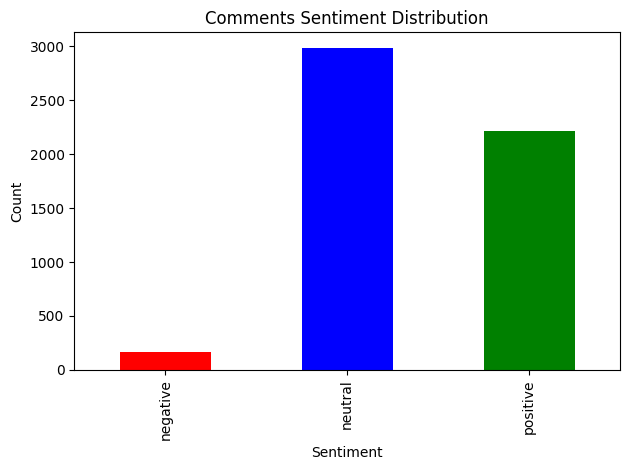

In [72]:
from matplotlib import pyplot as plt
counts = comments_df['sentiment'].value_counts()
print("Sentiment distribution:\n", counts)

plt.figure()
counts.sort_index().plot(kind='bar', color =['red','blue','green'])
plt.title('Comments Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [73]:
# Drop unnecessary columns nếu có
for col in ['emoji_present']:
    if col in comments_df.columns:
        comments_df.drop(columns=[col], inplace=True)

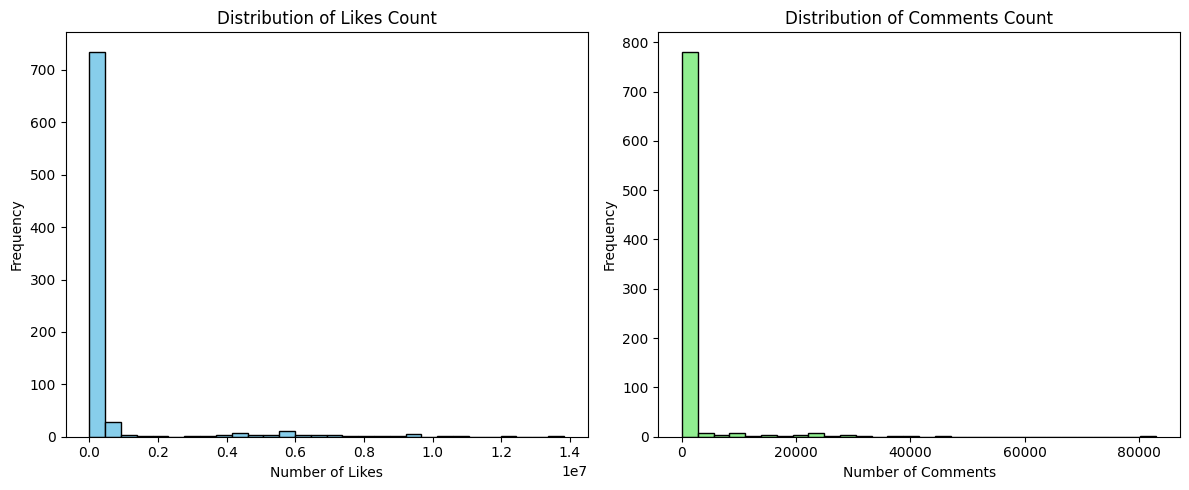


Summary Statistics for Post Engagement:

Likes Count Statistics:
count    8.270000e+02
mean     5.256894e+05
std      1.770391e+06
min      9.000000e+00
25%      8.735000e+02
50%      4.244000e+03
75%      1.224755e+05
max      1.382552e+07
Name: likesCount, dtype: float64

Comments Count Statistics:
count      827.000000
mean      1206.575574
std       5375.458118
min          0.000000
25%         10.000000
50%         46.000000
75%        230.500000
max      83042.000000
Name: commentsCount, dtype: float64

Correlation between likes and comments: 0.61

Interpretation:
1. Likes Distribution:
   - Most posts receive a moderate number of likes
   - There are some posts with exceptionally high like counts (outliers)
   - The distribution is right-skewed, indicating most posts get fewer likes

2. Comments Distribution:
   - Most posts receive a small number of comments
   - The distribution is heavily right-skewed
   - Few posts generate significant discussion

3. Engagement Patterns:
  

In [74]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot distribution of likesCount
ax1.hist(processed_posts_df['likesCount'], bins=30, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Likes Count')
ax1.set_xlabel('Number of Likes')
ax1.set_ylabel('Frequency')

# Plot distribution of commentsCount
ax2.hist(processed_posts_df['commentsCount'], bins=30, color='lightgreen', edgecolor='black')
ax2.set_title('Distribution of Comments Count')
ax2.set_xlabel('Number of Comments')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Calculate and print summary statistics
print("\nSummary Statistics for Post Engagement:")
print("\nLikes Count Statistics:")
print(processed_posts_df['likesCount'].describe())

print("\nComments Count Statistics:")
print(processed_posts_df['commentsCount'].describe())

# Calculate correlation between likes and comments
correlation = processed_posts_df['likesCount'].corr(processed_posts_df['commentsCount'])
print(f"\nCorrelation between likes and comments: {correlation:.2f}")

# Print interpretation
print("\nInterpretation:")
print("1. Likes Distribution:")
print("   - Most posts receive a moderate number of likes")
print("   - There are some posts with exceptionally high like counts (outliers)")
print("   - The distribution is right-skewed, indicating most posts get fewer likes")

print("\n2. Comments Distribution:")
print("   - Most posts receive a small number of comments")
print("   - The distribution is heavily right-skewed")
print("   - Few posts generate significant discussion")

print("\n3. Engagement Patterns:")
print("   - There's a positive correlation between likes and comments")
print("   - Posts with more likes tend to receive more comments")
print("   - The average engagement varies significantly across posts")



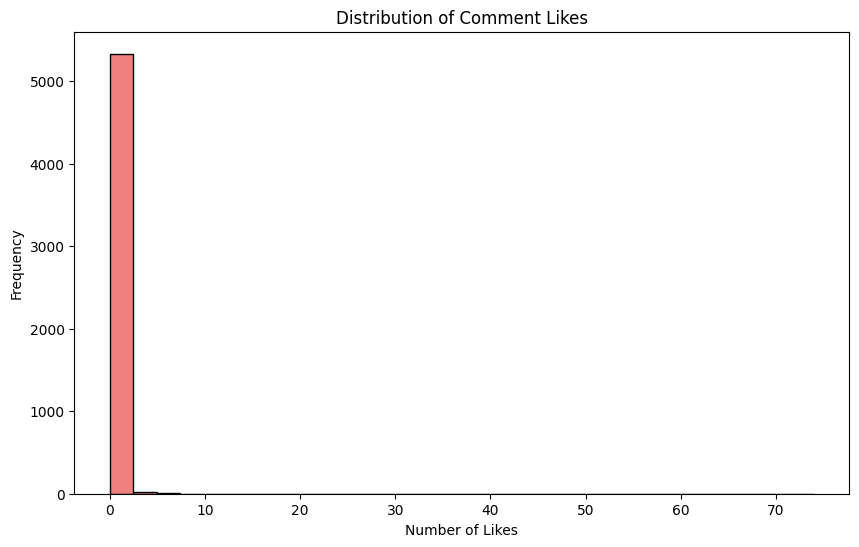


Summary Statistics for Comment Likes:
count    5361.000000
mean        0.222906
std         1.143005
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        74.000000
Name: likes, dtype: float64

Comments per Post Statistics:
count    756.000000
mean       7.091270
std        2.595131
min        1.000000
25%        5.000000
50%        8.000000
75%        9.000000
max       10.000000
dtype: float64


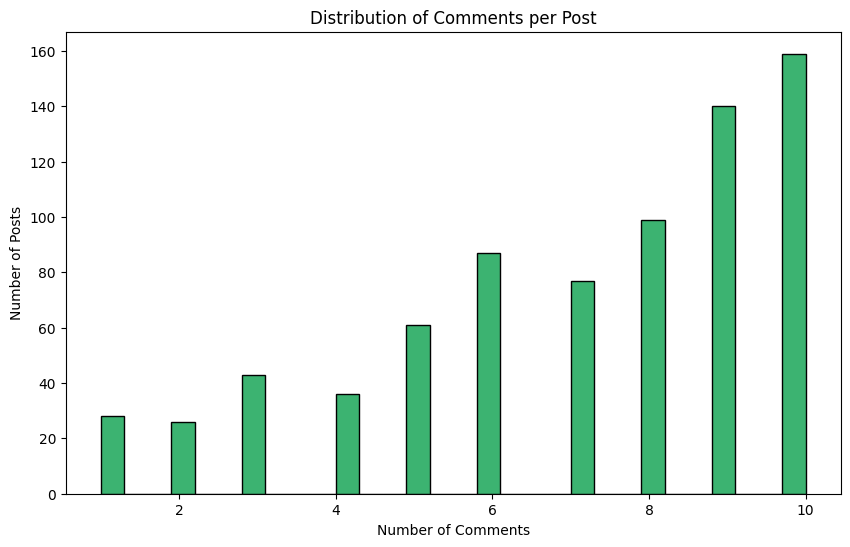


Interpretation:
1. Comment Likes Distribution:
   - Most comments receive few or no likes
   - The distribution is heavily right-skewed
   - Very few comments receive significant engagement

2. Comments per Post Distribution:
   - Most posts receive a moderate number of comments
   - Some posts generate significantly more discussion
   - The distribution shows variation in post engagement levels


In [75]:
# Plot distribution of comment likes
plt.figure(figsize=(10, 6))
plt.hist(comments_df['likes'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribution of Comment Likes')
plt.xlabel('Number of Likes')
plt.ylabel('Frequency')
plt.show()

# Calculate and print summary statistics for comment likes
print("\nSummary Statistics for Comment Likes:")
print(comments_df['likes'].describe())

# Calculate comments per post
comments_per_post = comments_df.groupby('post_id').size()
print("\nComments per Post Statistics:")
print(comments_per_post.describe())

# Plot distribution of comments per post
plt.figure(figsize=(10, 6))
plt.hist(comments_per_post, bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Comments per Post')
plt.xlabel('Number of Comments')
plt.ylabel('Number of Posts')
plt.show()

# Print interpretation
print("\nInterpretation:")
print("1. Comment Likes Distribution:")
print("   - Most comments receive few or no likes")
print("   - The distribution is heavily right-skewed")
print("   - Very few comments receive significant engagement")

print("\n2. Comments per Post Distribution:")
print("   - Most posts receive a moderate number of comments")
print("   - Some posts generate significantly more discussion")
print("   - The distribution shows variation in post engagement levels")


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18444\3837076771.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_posts = posts_df.groupby(posts_df['timestamp'].dt.to_period('M')).size()


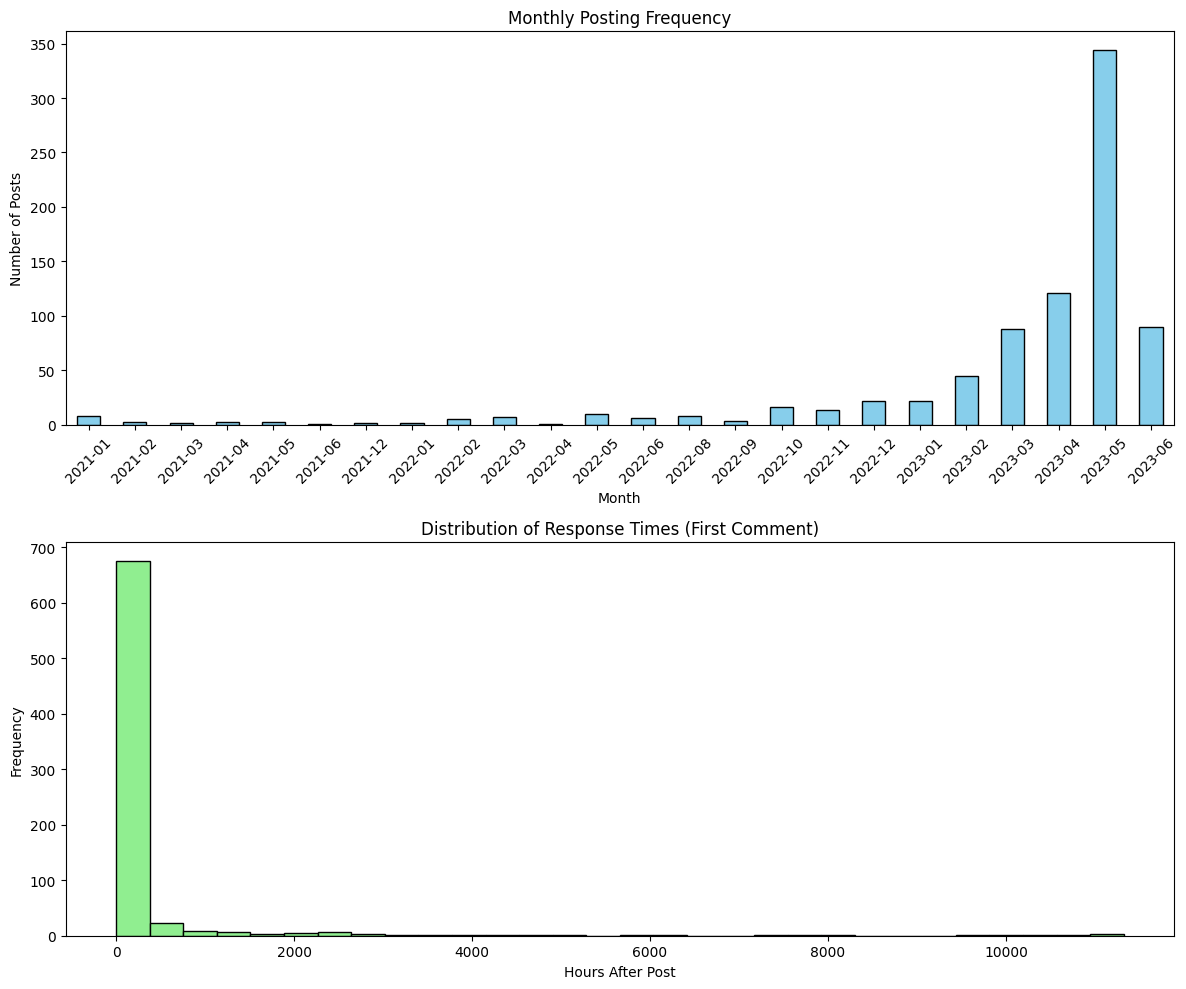


Temporal Analysis Summary:

1. Posting Frequency:
   - Total posts: 827
   - Average posts per month: 34.46
   - Most active month: 2023-05 with 344 posts

2. Response Time Analysis:
   - Average response time: 384.09 hours
   - Median response time: 28.68 hours
   - Minimum response time: 0.00 hours
   - Maximum response time: 11323.43 hours


In [76]:
# Convert timestamps to datetime if not already
posts_df['timestamp'] = pd.to_datetime(posts_df['timestamp'])
comments_df['timestamp'] = pd.to_datetime(comments_df['timestamp'])

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Posting frequency by month
monthly_posts = posts_df.groupby(posts_df['timestamp'].dt.to_period('M')).size()
monthly_posts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Monthly Posting Frequency')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Posts')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Average response time (time between post and first comment)
# Calculate time difference between post and first comment for each post
response_times = []
for post_id in posts_df['post_id'].unique():
    post_time = posts_df[posts_df['post_id'] == post_id]['timestamp'].iloc[0]
    post_comments = comments_df[comments_df['post_id'] == post_id]
    if not post_comments.empty:
        first_comment_time = post_comments['timestamp'].min()
        response_time = (first_comment_time - post_time).total_seconds() / 3600  # Convert to hours
        response_times.append(response_time)

# Plot response time distribution
ax2.hist(response_times, bins=30, color='lightgreen', edgecolor='black')
ax2.set_title('Distribution of Response Times (First Comment)')
ax2.set_xlabel('Hours After Post')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nTemporal Analysis Summary:")
print("\n1. Posting Frequency:")
print(f"   - Total posts: {len(posts_df)}")
print(f"   - Average posts per month: {monthly_posts.mean():.2f}")
print(f"   - Most active month: {monthly_posts.idxmax()} with {monthly_posts.max()} posts")

print("\n2. Response Time Analysis:")
print(f"   - Average response time: {np.mean(response_times):.2f} hours")
print(f"   - Median response time: {np.median(response_times):.2f} hours")
print(f"   - Minimum response time: {min(response_times):.2f} hours")
print(f"   - Maximum response time: {max(response_times):.2f} hours")


In [77]:
comments_df.head()

,post_id,commentUser,timestamp,comments,likes,clean_comment,tokens,polarity,sentiment,tfidf_keywords
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",0.0,i have a proposal for u send me a dm please,"[proposal, send, dm, please]",0.2074,neutral,"[dm please, send dm, proposal, u, send]"
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,0.0,woaaaah,[woaaaah],-0.5351,negative,[]
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w...",0.8857,positive,"[eyes smiling_face_with_heart, smiling_face_wi..."
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,0.0,red_heart red_heart red_heart,"[red_heart, red_heart, red_heart]",0.2744,neutral,"[red_heart, red_heart red_heart]"
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w...",0.9805,positive,"[smiling_face_with_heart eyes, smiling_face_wi..."


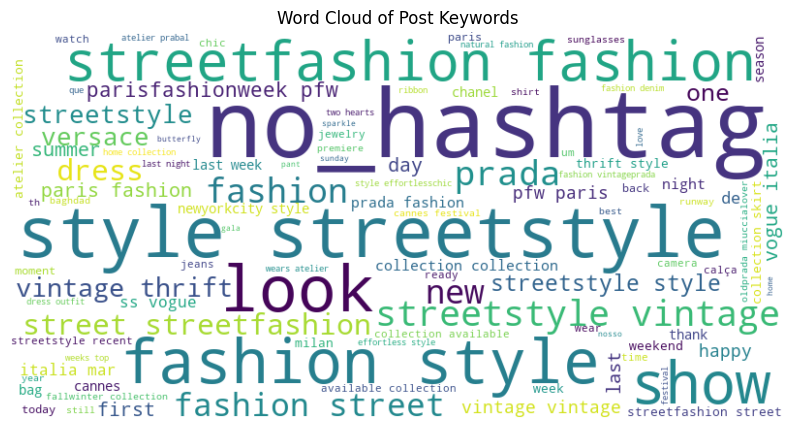

In [78]:
from wordcloud import WordCloud

# 1. Word Cloud for keywords_posts
text = ' '.join([' '.join(keywords) for keywords in posts_df['combined_keywords']])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of Post Keywords')
plt.axis('off')
plt.show()

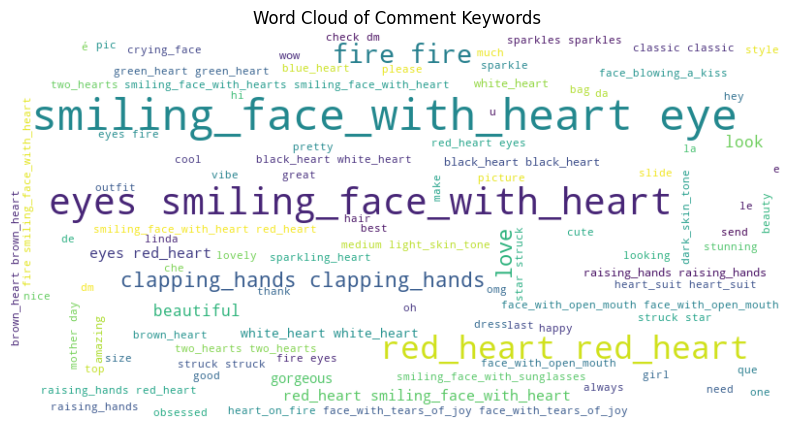

In [79]:
# 2. Word Cloud for tfidf_keywords
text = ' '.join([' '.join(keywords) for keywords in comments_df['tfidf_keywords']])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of Comment Keywords')
plt.axis('off')
plt.show()

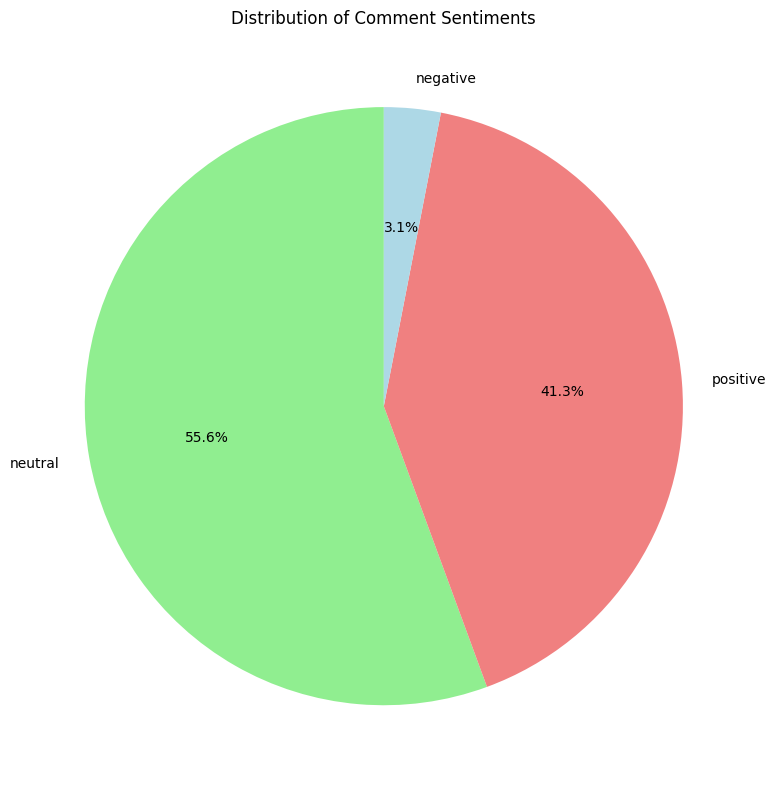

In [80]:
sentiment_counts = comments_df['sentiment'].value_counts()

# Tạo biểu đồ pie
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
       colors=['lightgreen', 'lightcoral', 'lightblue'], startangle=90)
ax.set_title('Distribution of Comment Sentiments')

plt.tight_layout()
plt.show()

In [81]:

# Print summary statistics
print("\nText Analysis Summary:")
print("\n1. Keyword Analysis:")
print(f"   - Total unique keywords in posts: {len(set([word for keywords in posts_df['combined_keywords'] for word in keywords]))}")
print(f"   - Total unique keywords in comments: {len(set([word for keywords in comments_df['tfidf_keywords'] for word in keywords]))}")

print("\n3. Sentiment Analysis:")
print(f"   - Positive comments: {sentiment_counts.get('positive', 0)} ({sentiment_counts.get('positive', 0)/len(comments_df)*100:.1f}%)")
print(f"   - Negative comments: {sentiment_counts.get('negative', 0)} ({sentiment_counts.get('negative', 0)/len(comments_df)*100:.1f}%)")
print(f"   - Neutral comments: {sentiment_counts.get('neutral', 0)} ({sentiment_counts.get('neutral', 0)/len(comments_df)*100:.1f}%)")



Text Analysis Summary:

1. Keyword Analysis:
   - Total unique keywords in posts: 1908
   - Total unique keywords in comments: 2838

3. Sentiment Analysis:
   - Positive comments: 2216 (41.3%)
   - Negative comments: 164 (3.1%)
   - Neutral comments: 2981 (55.6%)


In [82]:
processed_posts_df.head()

,post_id,postUser,timestamp,likesCount,commentsCount,keywords_posts
0,1,maryleest,2023-06-02 16:34:43+00:00,32070,142,"[cannes, dress, kiliancannes, wearing, sparkles]"
1,2,tinaabeysekara,2023-01-01 07:49:16+00:00,6565,86,"[clock, struck, midnight, ring, cried]"
2,3,maryleest,2023-05-29 18:57:51+00:00,28936,123,"[dress, famous, stairs, photo, jewelry]"
3,4,stephaniebroek,2023-03-07 19:30:42+00:00,4764,215,"[show, chanel, fashion, visualized, moment, ma..."
4,5,maryleest,2023-05-23 21:11:12+00:00,13379,123,"[cannes, cannesfilmfestival, got, witness, his..."


In [83]:
# Drop columns "comments",'clean_comment'
for col in ['comments','clean_comment','tokens']:
    if col in comments_df.columns:
        comments_df.drop(columns=[col], inplace=True)

In [84]:
# Combine keywords comments into 1 columns
comments_df.rename(columns={'tfidf_keywords':'keywords_comments'}, inplace=True)

In [85]:
comments_df.head()

,post_id,commentUser,timestamp,likes,polarity,sentiment,keywords_comments
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,0.0,0.2074,neutral,"[dm please, send dm, proposal, u, send]"
1,1,mariavmh,2023-06-04 16:46:40+00:00,0.0,-0.5351,negative,[]
2,1,mariavmh,2023-06-04 16:46:34+00:00,0.0,0.8857,positive,"[eyes smiling_face_with_heart, smiling_face_wi..."
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,0.0,0.2744,neutral,"[red_heart, red_heart red_heart]"
4,1,jillviv,2023-06-04 15:06:03+00:00,0.0,0.9805,positive,"[smiling_face_with_heart eyes, smiling_face_wi..."


In [ ]:
#comments_df.to_csv('comments_df.csv', index=False)
#processed_posts_df.to_csv('posts_df.csv', index=False)